In [9]:



import pandas as pd

df = pd.read_csv('dirty_cafe_sales.csv')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [14]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Item'].fillna('Unknown', inplace=True)
df['Location'].fillna('Unknown', inplace=True)
df['Payment Method'].fillna('Unknown', inplace=True)

df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              9667 non-null   str           
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   str           
 6   Location          6735 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 625.1 KB


C:\Users\likit\AppData\Local\Temp\ipykernel_8064\2216525544.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Item'].fillna('Unknown', inplace=True)
C:\Users\likit\AppData\Local\Temp\ipykernel_8064\2216525544.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using a

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [17]:
#fill text columns - assigns back instead of inplace
df['Item'] = df['Item'].fillna('Unknown')
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')

#drop rows where critical numbers/dates are missing
df = df.dropna(subset=['Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date'])

#drop duplicates
print("Rows before duplicates:", len(df))
df = df.drop_duplicates()
print("Rows after duplicates:", len(df))

#fix total spet calculation - lots of bad data in this dataset
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

df.info()
df.isnull().sum()

Rows before duplicates: 8159
Rows after duplicates: 8159
<class 'pandas.DataFrame'>
Index: 8159 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    8159 non-null   str           
 1   Item              8159 non-null   str           
 2   Quantity          8159 non-null   float64       
 3   Price Per Unit    8159 non-null   float64       
 4   Total Spent       8159 non-null   float64       
 5   Payment Method    8159 non-null   str           
 6   Location          8159 non-null   str           
 7   Transaction Date  8159 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 573.7 KB


Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


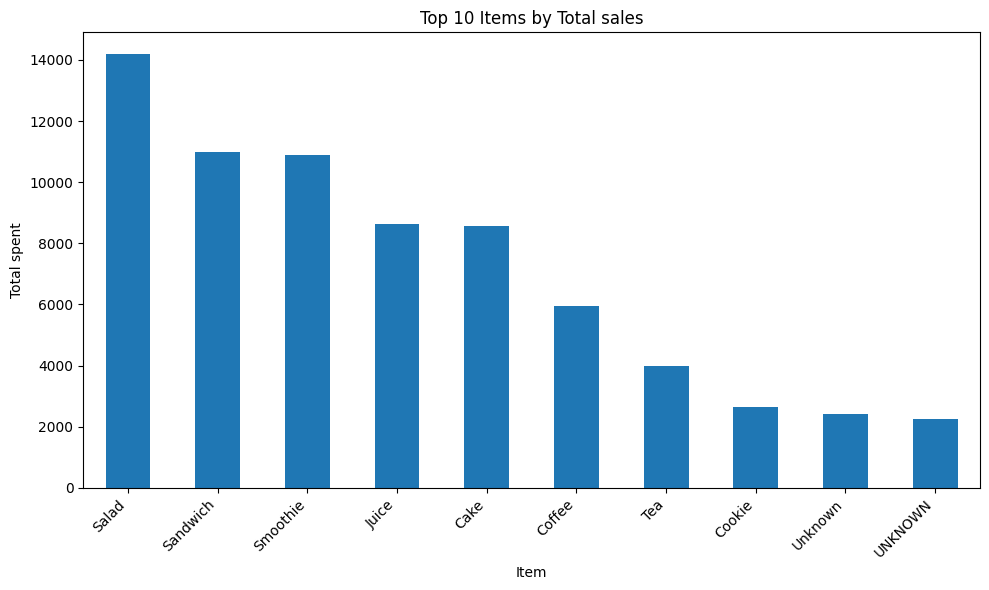

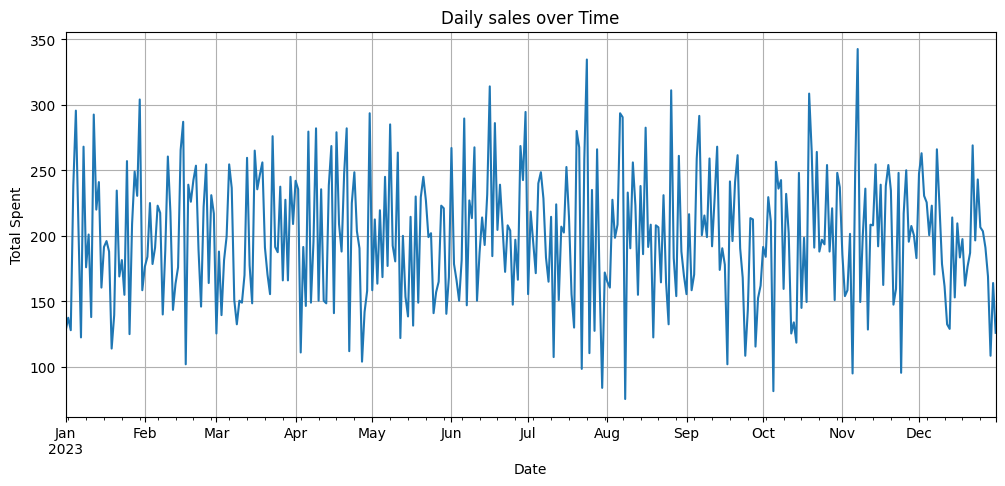

Total Revenue: $ 72704.5
Average Transaction: $ 8.91
Most Popular Item: Juice
Top payment Method: Unknown


In [20]:
import matplotlib.pyplot as plt

#total sales by item
sales_by_item = df.groupby('Item') ['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sales_by_item.head(10).plot(kind="bar")
plt.title('Top 10 Items by Total sales')
plt.ylabel('Total spent')
plt.xlabel('Item')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#sales over time
df_daily = df.groupby('Transaction Date') ['Total Spent'].sum()

plt.figure(figsize=(12,5))
df_daily.plot()
plt.title('Daily sales over Time')
plt.ylabel('Total Spent')
plt.xlabel('Date')
plt.grid(True)
plt.show()

#quick status
print("Total Revenue: $", round(df['Total Spent'].sum(), 2))
print("Average Transaction: $", round(df['Total Spent'].mean(), 2))
print("Most Popular Item:", df['Item'].mode()[0])
print("Top payment Method:", df['Payment Method'].mode()[0])

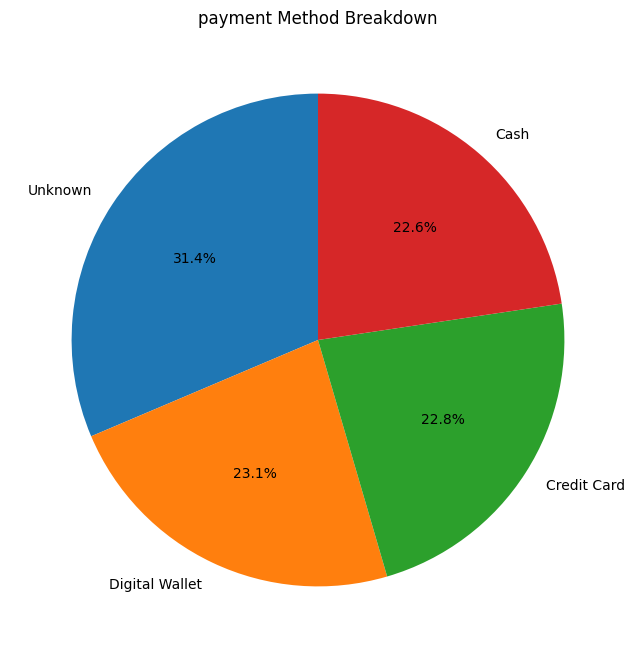

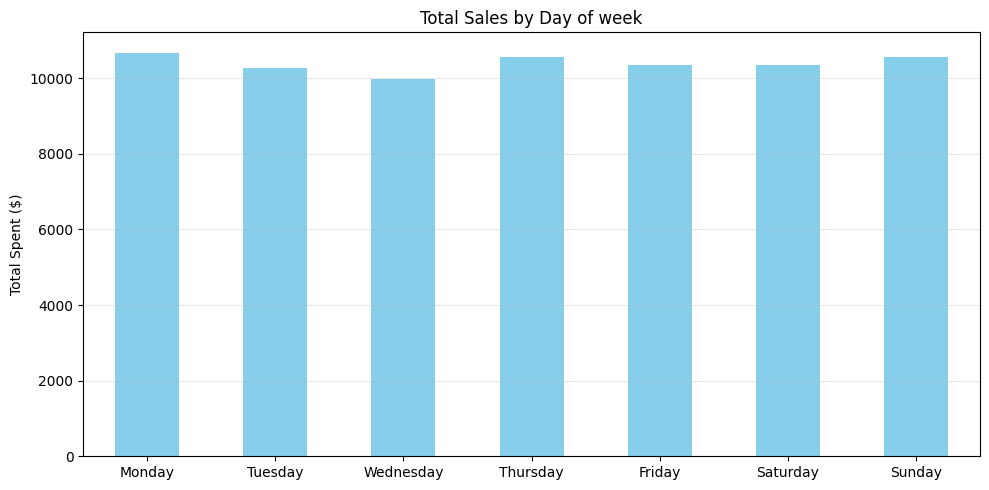

In [27]:
#standardize the text - make all unknowns the same
df['Payment Method'] = df['Payment Method'].str.title()
df['Payment Method'] = df['Payment Method'].replace('Error', 'Unknown')

df['Payment Method'].value_counts()

plt.figure(figsize=(8,8))
payment_counts =df['Payment Method'].value_counts()

plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('payment Method Breakdown')
plt.ylabel('')
plt.show()

df['weekday'] = df['Transaction Date'].dt.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('weekday')['Total Spent'].sum().reindex(days)

plt.figure(figsize=(10,5))
weekday_sales.plot(kind='bar' , color='skyblue')
plt.title('Total Sales by Day of week')
plt.ylabel('Total Spent ($)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
print("=== CAFE SALES INSIGHTS ===")
print(f"1. Clean Records Analyzed: {len(df):,}")
print(f"2. Total Revenue: ${df['Total Spent'].sum():,.0f}")
print(f"3. Top Item: {df['Item'].mode()[0]} at ${df.groupby('Item')['Total Spent'].sum().max():,.0f}")
print(f"4. Data Issue: {(df['Payment Method']== 'Unknown').sum() / len(df):.1%} payments missing method")
print(f"5. Sales Pattern: Flat across all 7 days, avg ${df.groupby(df['Transaction Date'].dt.day_name())['Total Spent'].sum().mean():,.0f}/day")


df.to_csv('clean_cafe_sales.csv', index=False)
print("\nSaved clean_cafe_sales.csv -ready for portfolio")


=== CAFE SALES INSIGHTS ===
1. Clean Records Analyzed: 8,159
2. Total Revenue: $72,704
3. Top Item: Juice at $14,195
4. Data Issue: 31.4% payments missing method
5. Sales Pattern: Flat across all 7 days, avg $10,386/day

Saved clean_cafe_sales.csv -ready for portfolio
